In [21]:
import matplotlib.pyplot as plt

# 开全局字体，加这行就够了
plt.rcParams['font.sans-serif'] = ['SimHei']   # 用黑体
plt.rcParams['axes.unicode_minus'] = False      # 解决负号显示问题



#如果 SimHei 不行，试试其他字体：
# Windows 可用的中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # 微软雅黑
# 或者
plt.rcParams['font.sans-serif'] = ['SimSun']   # 宋体
# 或者
plt.rcParams['font.sans-serif'] = ['KaiTi']    # 楷体



In [22]:
import cv2
import numpy as np
from PIL import Image, ImageDraw, ImageFont

def cv2_put_chinese(img, text, position, font_size=30, color=(0, 255, 0)):
    """在 OpenCV 图片上写中文"""
    # OpenCV BGR → PIL RGB
    img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    draw = ImageDraw.Draw(img_pil)

    # 加载中文字体（Windows 系统自带）
    font = ImageFont.truetype('C:/Windows/Fonts/simhei.ttf', font_size)

    # 写中文
    draw.text(position, text, font=font, fill=color[::-1])  # RGB 顺序

    # PIL → OpenCV BGR
    return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

📸 步骤1：准备图片...
✅ 图片读取成功！
   类型: <class 'numpy.ndarray'>
   形状: (872, 1440, 3)
   数据类型: uint8
   左上角像素值(BGR): [ 0 69 32]

📸 步骤2：BGR → RGB 转换...
📸 步骤3：显示原始图像...


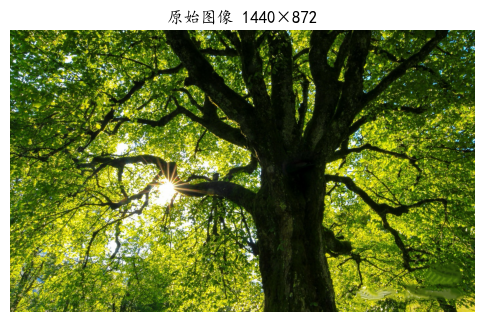


📸 步骤4：调整亮度...


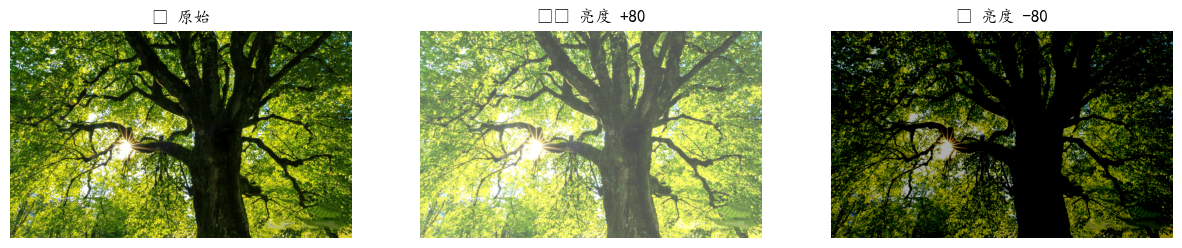

📸 步骤5：调整对比度...


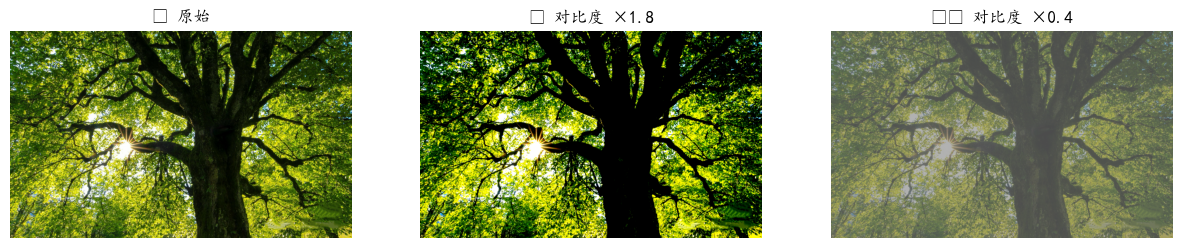

📸 步骤6：组合效果（亮度+对比度同时调整）...


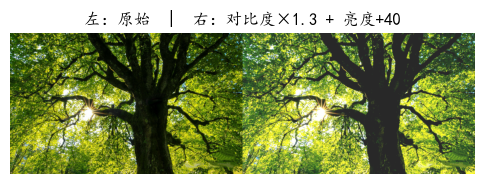

📸 步骤7：查看直方图...


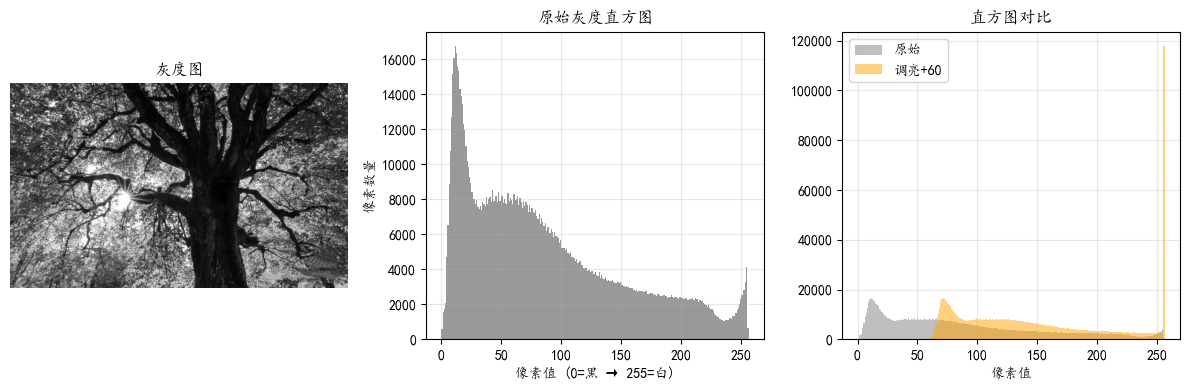

📸 步骤8：色彩空间转换...


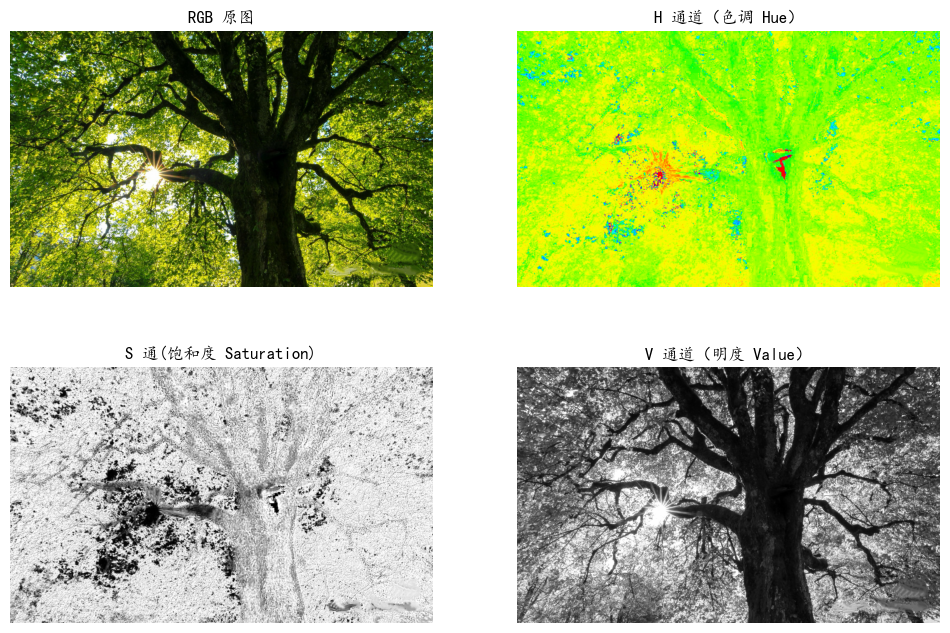


🎉 综合练习完成！你刚刚学会了：
  ✅ OpenCV 读取图像
  ✅ Matplotlib 显示图像
  ✅ BGR ↔ RGB 色彩空间转换
  ✅ 调整亮度（加减常数）
  ✅ 调整对比度（乘系数）
  ✅ 灰度直方图分析
  ✅ RGB → HSV 色彩空间转换
  ✅ 验证了：图像 = NumPy 数字矩阵


In [ ]:


import cv2
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# 1. 找一张图片
# ============================================
# 随便找一张 jpg/png 放到脚本同目录下，或者用下面代码生成一张测试图
print("📸 步骤1：准备图片...")

# 如果你没有图片，取消下面两行的注释，会生成一张彩色测试图
# test_img = np.random.randint(0, 255, (200, 300, 3), dtype=np.uint8)
# cv2.imwrite('test_image.png', test_img)

# 读取图片（换成你的文件名）
img = cv2.imread('tree.jpg')   # ← 改成你的图片文件名

# 如果读不到，试试绝对路径
# img = cv2.imread(r'D:\桌面\study-checkin\my_photo.jpg')

if img is None:
    print("❌ 没找到图片，我帮你生成一张彩虹测试图吧！")
    # 生成一张渐变色图片
    img = np.zeros((300, 400, 3), dtype=np.uint8)
    for i in range(300):
        for j in range(400):
            img[i, j] = [i * 0.8, j * 0.6, 128]
    cv2.imwrite('rainbow.png', img)
    print("✅ 已生成 rainbow.png")
    img = cv2.imread('rainbow.png')

print(f"✅ 图片读取成功！")
print(f"   类型: {type(img)}")       # numpy.ndarray ← 图像本质就是数组！
print(f"   形状: {img.shape}")       # (高, 宽, 通道数)
print(f"   数据类型: {img.dtype}")   # uint8 (0~255)
print(f"   左上角像素值(BGR): {img[0, 0]}")

# ============================================
# 2. BGR → RGB 转换（Matplotlib 显示用）
# ============================================
print("\n📸 步骤2：BGR → RGB 转换...")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# ============================================
# 3. 显示原始图像
# ============================================
print("📸 步骤3：显示原始图像...")

plt.figure("原始图像", figsize=(6, 4))
plt.imshow(img_rgb)
plt.title(f'原始图像 {img.shape[1]}×{img.shape[0]}')
#img.shape[0] = 图像高度（行数）
# img.shape[1] = 图像宽度（列数）
plt.axis('off')
plt.show()

# ============================================
# 4. 调整亮度（加减常数）
# ============================================
print("\n📸 步骤4：调整亮度...")

def adjust_brightness(image, value):
    """value > 0 变亮，value < 0 变暗"""
    result = image.astype(np.int32) + value
    result = np.clip(result, 0, 255)     # 限制在 0~255
    return result.astype(np.uint8)
# astype(np.int32)	先转成 int32，防止 uint8 加法溢出（255+10=265>255 会出错）
# + value	所有像素统一加上偏移量（正值变亮，负值变暗）
# np.clip(result, 0, 255)	裁剪到 [0, 255] 合法范围，防止过曝/过暗
# astype(np.uint8)	转回图像标准格式

img_bright = adjust_brightness(img_rgb, 80)   # 变亮
img_dark   = adjust_brightness(img_rgb, -80)  # 变暗

# 并排对比
plt.figure("亮度调整", figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('🌑 原始')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_bright)
plt.title('☀️ 亮度 +80')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_dark)
plt.title('🌙 亮度 -80')
plt.axis('off')

plt.show()

# ============================================
# 5. 调整对比度（乘系数）
# ============================================
print("📸 步骤5：调整对比度...")

def adjust_contrast(image, factor):
    """factor > 1 增强对比度，< 1 降低对比度"""
    # 公式：(像素值 - 128) × factor + 128
    result = (image.astype(np.float32) - 128) * factor + 128
    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

img_high_contrast = adjust_contrast(img_rgb, 1.8)   # 高对比度
img_low_contrast  = adjust_contrast(img_rgb, 0.4)   # 低对比度

# 并排对比
plt.figure("对比度调整", figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('🌑 原始')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_high_contrast)
plt.title('🔥 对比度 ×1.8')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_low_contrast)
plt.title('🌫️ 对比度 ×0.4')
plt.axis('off')

plt.show()

# ============================================
# 6. 亮度 + 对比度 一起调
# ============================================
print("📸 步骤6：组合效果（亮度+对比度同时调整）...")

img_combined = adjust_contrast(img_rgb, 1.3)   # 先增强对比度
img_combined = adjust_brightness(img_combined, 40)  # 再调亮

plt.figure("组合效果", figsize=(6, 4))
plt.imshow(np.hstack([img_rgb, img_combined]))
#np.hstack([img_rgb, img_combined]) — 将两张图水平拼在
plt.title('左：原始  |  右：对比度×1.3 + 亮度+40')
plt.axis('off')
plt.show()

# ============================================
# 7. 直方图 — 看看像素分布
# ============================================
print("📸 步骤7：查看直方图...")

plt.figure("灰度直方图", figsize=(12, 4))

# 原始灰度直方图
plt.subplot(1, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('灰度图')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.hist(img_gray.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.8)
# img_gray.ravel()	将二维灰度图展平为一维数组（每个像素一个值 0~255）
# bins=256	分成 256 个柱，每个代表一个灰度级
# range=[0, 256]	像素值范围 0（黑）~ 255（白）
# color='gray'	柱子灰色
# alpha=0.8	透明度 0.8

plt.title('原始灰度直方图')
plt.xlabel('像素值 (0=黑 → 255=白)')
plt.ylabel('像素数量')
plt.grid(alpha=0.3)

# 调亮后的直方图对比
gray_bright = np.clip(img_gray.astype(np.int32) + 60, 0, 255).astype(np.uint8)
plt.subplot(1, 3, 3)
plt.hist(img_gray.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.5, label='原始')
plt.hist(gray_bright.ravel(), bins=256, range=[0, 256], color='orange', alpha=0.5, label='调亮+60')
plt.title('直方图对比')
plt.xlabel('像素值')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()#作用： 自动调整子图之间的间距、边距，防止标签、标题、刻度被裁切或重叠。
plt.show()

# ============================================
# 8. 色彩空间转换（HSV）
# ============================================
print("📸 步骤8：色彩空间转换...")

img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

plt.figure("色彩空间", figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('RGB 原图')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img_hsv[:, :, 0], cmap='hsv')
plt.title('H 通道（色调 Hue）')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(img_hsv[:, :, 1], cmap='gray')
plt.title('S 通(饱和度 Saturation)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_hsv[:, :, 2], cmap='gray')
plt.title('V 通道（明度 Value）')
plt.axis('off')

plt.show()

print("\n" + "="*50)
print("🎉 综合练习完成！你刚刚学会了：")
print("  ✅ OpenCV 读取图像")
print("  ✅ Matplotlib 显示图像")
print("  ✅ BGR ↔ RGB 色彩空间转换")
print("  ✅ 调整亮度（加减常数）")
print("  ✅ 调整对比度（乘系数）")
print("  ✅ 灰度直方图分析")
print("  ✅ RGB → HSV 色彩空间转换")
print("  ✅ 验证了：图像 = NumPy 数字矩阵")
print("="*50)